# The `Cask` Class

The {py:obj}`Cask <snf_simulations.cask.Cask>` class, defined in the {py:obj}`snf_simulations.cask <snf_simulations.cask>` module, is the primary interface for simulating spent nuclear fuel (SNF) casks.

A single `Cask` object represents a single SNF cask, and is built around a {py:obj}`Spectrum <snf_simulations.spec.Spectrum>` object that represents the combined antineutrino spectrum from all isotopes in the cask.

## Creating a `Cask`

In order to simulate a cask, we need two properties:
* The mass of SNF, in kg
* The proportions of isotopes in the cask

For the latter, the proportions are currently defined for two sample reactors, Sizewell and Hartlepool.

:::{note}
In the future different proportions should be able to be added using a [FISPIN](https://www.answerssoftwareservice.com/fispin) output file. See [this GitHub Issue](https://github.com/ekneale/SNF-simulations/issues/17) for details.
:::

To create a `Cask` object, we can use the {py:func}`from_reactor <snf_simulations.cask.Cask.from_reactor>` class method, which takes the mass of SNF and the name of the reactor as input. For example:

In [4]:
from snf_simulations.cask import Cask

# Create a Cask object for 100 kg of SNF from the Sizewell reactor
reactor = "sizewell"
mass = 10000  # 10 tonnes
cask = Cask.from_reactor(reactor, total_mass=mass)
print(cask)

<Cask "sizewell_cask", total_mass=10000 kg>


The main function of the `Cask` class is to calculate the combined antineutrino spectrum from all isotopes in the cask, which is done using the {py:func}`get_total_spectrum <snf_simulations.cask.Cask.get_total_spectrum>` method. This method uses the proportions of isotopes in the cask, and the corresponding spectra for each isotope, to calculate the total spectrum for the cask. For example we can get the total spectrum of the cask we just created and plot it:

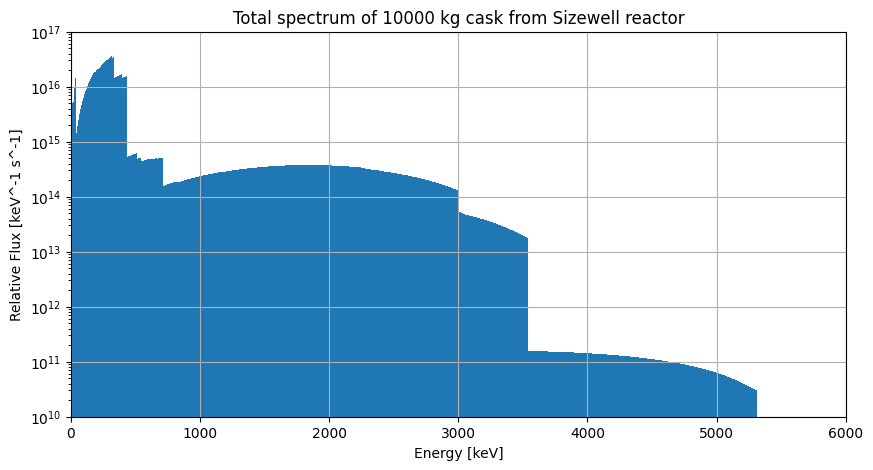

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get the total spectrum for the cask
total_spec = cask.get_total_spectrum()

# Plot the spectrum
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

axes.bar(
    x=total_spec.energy[:-1],
    height=total_spec.flux,
    width=np.diff(total_spec.energy),
)

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e17)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total spectrum of {cask.total_mass} kg cask from {reactor.capitalize()} reactor")
axes.set_yscale("log")
axes.grid()

plt.show()

## Simulating the SNF spectrum after removal from the reactor

We can also simulate the antineutrino spectrum from the SNF after any given removal time, which includes modeling the activity levels and decay chains.

This is done using the same {py:func}`get_total_spectrum <snf_simulations.cask.Cask.get_total_spectrum>` method, which takes an optional `removal_time` parameter that specifies the time since the SNF was removed from the reactor, in years. For example we can plot the total spectrum for our cask after multiple different removal times:

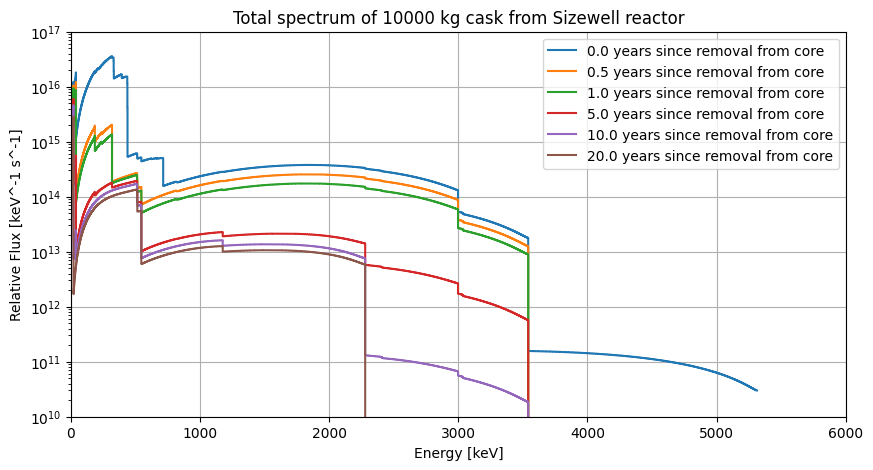

In [6]:
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

removal_times = [0, 0.5, 1, 5, 10, 20]
for removal_time in removal_times:
    total_spec = cask.get_total_spectrum(removal_time=removal_time)
    axes.step(
        total_spec.energy[:-1],
        total_spec.flux,
        where="post",
        label=f"{removal_time:.1f} years since removal from core",
    )

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e17)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total spectrum of {cask.total_mass} kg cask from {reactor.capitalize()} reactor")
axes.set_yscale("log")
axes.grid()
axes.legend()

plt.show()